In [171]:
import numpy as np
from PIL import Image as PILImage
from matplotlib import pyplot as plt
import misalign.canvas.canvas_rectangular as cr

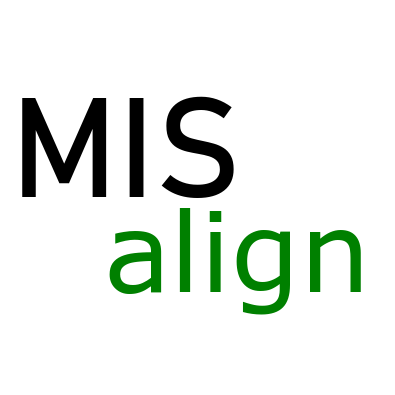

In [64]:
# reference: https://matplotlib.org/stable/users/explain/text/text_intro.html
# reference: https://jonathansoma.com/lede/data-studio/matplotlib/list-all-fonts-available-in-matplotlib-plus-samples/
plt.text(x=0,y=0.2,s="MIS",
    fontsize=100,
    color="black",
    # family='fantasy',
    font="Bahnschrift",
    )
plt.text(x=0.1,y=0.1,s="align",
    fontsize=80,
    color="green",
    # family='monospace',
    # font="Bahnschrift",
    # font="Arial",
    font="Verdana",
    )
plt.ylim(0,0.4)
plt.xlim(0,0.4)
plt.gca().set_axis_off()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.gcf().set_size_inches(4, 4)

plt.savefig("misalign_logo_r1.svg",dpi=300)
plt.savefig("misalign_logo_r1.png",dpi=300)
plt.savefig("misalign_logo_r1_small.png",dpi=75)

(655.0, 545.0)

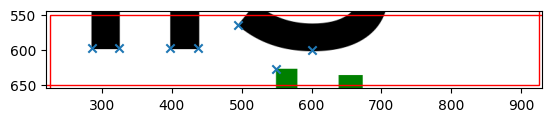

In [225]:
logo_array=np.asarray(PILImage.open("misalign_logo_r1.png"))
plt.imshow(logo_array)
xy_mis=(0,200)
xy_align=(225,550)
width=925
height=450 #410
plt.gca().add_artist(plt.Rectangle(xy_mis,width,height,edgecolor="red",fill=False))
plt.gca().add_artist(plt.Rectangle(xy_align,width,height,edgecolor="red",fill=False))

points=[(285,598),(325,598),(398,598),(438,598),(495,565),(600,600),(549,627)]
plt.scatter([point[0] for point in points],[point[1] for point in points],marker="x")

plt.xlim(xy_align[0]-5,xy_mis[0]+width+5)
plt.ylim(xy_mis[1]+height+5,xy_align[1]-5)

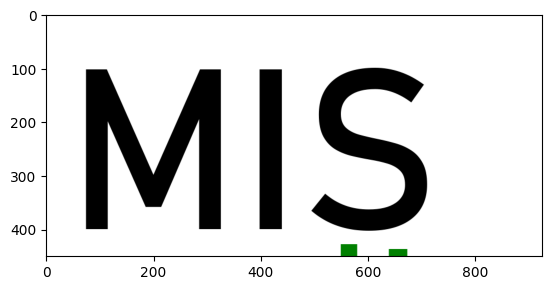

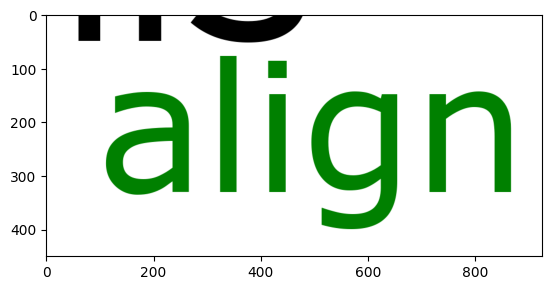

In [226]:
plt.imshow(logo_array[xy_mis[1]:xy_mis[1]+height,xy_mis[0]:xy_mis[0]+width])
plt.figure()
plt.imshow(logo_array[xy_align[1]:xy_align[1]+height,xy_align[0]:xy_align[0]+width])
# plt.plot([pop[0][0],pop[1][0]],[pop[0][1],pop[1][1]+self._height],"x:")

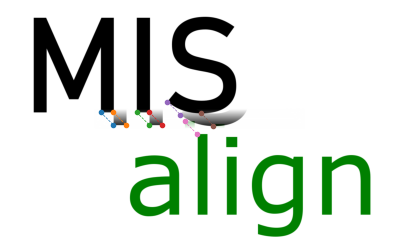

In [250]:
image_arrays={
        "mis":logo_array[xy_mis[1]:xy_mis[1]+height,xy_mis[0]:xy_mis[0]+width,:-1],
        "align":logo_array[xy_align[1]:xy_align[1]+height,xy_align[0]:xy_align[0]+width,:-1]
    }
canvas_extents={"width":1200,"height":1200}

misalignment=np.array([40,40])

canvas_relative_offsets={
        "mis":xy_mis,
        "align":misalignment+xy_align # introduce intentional misalignment.
    }
normalizer=cr.build_normalization(
    image_arrays=image_arrays,  # ty:ignore[invalid-argument-type]
    canvas_relative_offsets=canvas_relative_offsets,
    canvas_extents=canvas_extents,
    weight=cr.weight_dfe,
    )
blended_canvas_dfe=cr.render_blended(
    image_arrays=image_arrays,  # ty:ignore[invalid-argument-type]
    canvas_relative_offsets=canvas_relative_offsets,
    canvas_extents=canvas_extents,
    weight=cr.weight_dfe,
    normalizer=normalizer
    )
blended_canvas_dfe+=np.repeat(255*(normalizer==0)[:,:,np.newaxis],repeats=3,axis=2)
plt.imshow(blended_canvas_dfe)

for point in points:
    point_array=np.array([point,misalignment+point])
    plt.plot(point_array[:,0],point_array[:,1],marker=".",linestyle="--",linewidth=0.5)


plt.gca().set_axis_off()
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.gcf().set_size_inches(4, 4)
plt.savefig("misalign_logo_r2.png",dpi=300)
plt.savefig("misalign_logo_r2_small.png",dpi=75)
plt.ylim(1000,275)
plt.gcf().set_size_inches(4, 4*(750/1200))
plt.savefig("misalign_logo_r2_wide.png",dpi=300)

In [202]:
misalignment=np.array([25,25])

In [204]:

for point in points:
    print(np.array([point,misalignment+point]))

[[285 598]
 [310 623]]
[[325 598]
 [350 623]]
[[398 598]
 [423 623]]
[[438 598]
 [463 623]]
[[495 565]
 [520 590]]
[[600 600]
 [625 625]]
